# Análise de dados de Sistema de Monitoramento

O presente trabalho tem como objetivo analisar os dados das avaliações Diagnósticas aplicadas no programa PBA Sergipe para entender a eficácia pedagógica do programa através de seus instrumentos.

## Importando bibliotecas e dados

In [2]:
# Importando bibliotecas
import pandas as pd
import re
import matplotlib.pyplot as plt
from matplotlib import patheffects
import seaborn as sns
import os
import geopandas as gpd
import contextily as ctx
import textwrap

# Importando arquivo
df_cadastro = pd.read_excel(
    'Data_files/public_data/xls_pedagogico_09062025.xlsx')
df_turmas = pd.read_excel(
    'Data_files/public_data/turmas_09062025.xlsx')
df_registros = pd.read_excel(
    'Data_files/public_data/xls_detalhado_09062025.xlsx')
df_relatorios_diagnostica = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_diagostica_09062025.xlsx')

print(df_cadastro.info())
print(df_cadastro.head())

print(df_turmas.info())
print(df_turmas.head())

print(df_registros.info())
print(df_registros.head())

print(df_relatorios_diagnostica.info())
print(df_relatorios_diagnostica.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4044 entries, 0 to 4043
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CPF                        4044 non-null   object 
 1   Nome                       4044 non-null   object 
 2   Turma                      4044 non-null   object 
 3   Data de início             4044 non-null   object 
 4   Alfabetizador              4044 non-null   object 
 5   Coordenador                4044 non-null   object 
 6   Qtde presença              4044 non-null   int64  
 7   Qtde ausência              4044 non-null   int64  
 8   Atividade - Entrada        3688 non-null   object 
 9   Atividade - Formativa 1    3536 non-null   object 
 10  Atividade - Formativa 2    2584 non-null   object 
 11  Atividade - Formativa 3    818 non-null    object 
 12  Atividade - Formativa 4    0 non-null      float64
 13  Atividade - Saída          0 non-null      float

## Tratando dos dados
Se faz necessário a transformação dos dados para que seja mais fácil sua análise. De acordo com a observação dos dados apresentados, as seguintes transformações serão necessárias:
Em df_registros:
- Transformar nomes de cada coluna para o padrão snake_case;
- Extrair somente os níveis da coluna "Nível";
- Deixar os níveis de maneira categórica corretamente para melhor análise na coluna "Nível".

Em df_relatorios
- Transformar nomes de cada coluna para o padrão snake_case;
- As colunas que contém perguntas serão reduzidas somente a palavra "pergunta" seguida do seu número, exemplo: pergunta_1
- As categorias de resposta serão resumidas em no máximo 3 palavras para facilitar a interpretação - um dicionário será criado aqui. 

In [3]:
# Transformando nomes de colunas para padrão snake_case
# Função para converter para snake_case
def to_snake_case(column_name):
    return (
        column_name
        .lower()  # Converte tudo para minúsculo
        .replace(' ', '_')  # Substitui espaços por underscore
        .replace('é', 'e')  # Remove acentos
        .replace('ã', 'a')
        .replace('ç', 'c')
        .replace('í', 'i')
        .replace('ó', 'o')
        .replace('ú', 'u')
        .replace('á', 'a')
    )

# Função para extrair o número de perguntas e renomear
def renomear_perguntas(nome_coluna):
    match = re.match(r'^(\d+)\._', nome_coluna)  # Procura o padrão "X._" no início
    if match:
        numero = match.group(1)
        return f'pergunta_{numero}'
    return nome_coluna  # Mantém o nome original se não for uma pergunta numerada

# Aplica a função to_snake_case aos nomes das colunas
df_cadastro.columns = [to_snake_case(col) for col in df_cadastro.columns]
df_turmas.columns = [to_snake_case(col) for col in df_turmas.columns]
df_registros.columns = [to_snake_case(col) for col in df_registros.columns]
df_relatorios_diagnostica.columns = [to_snake_case(col) for col in df_relatorios_diagnostica.columns]

# Aplica a função renomear_perguntas a todas as colunas
df_relatorios_diagnostica.columns = [renomear_perguntas(col) for col in df_relatorios_diagnostica.columns]

# Extraindo somente os dados de nível em df_registros
df_registros['nivel'] = df_registros['nivel'].str.extract(r'(Nível [1-3])')

# Ordenando nívels de maneira categórica corretamente
df_registros['nivel'] = pd.Categorical(
    df_registros['nivel'],
    categories=['Nível 1', 'Nível 2', 'Nível 3'],
    ordered=True)

# Verificando os tipos de dados e informações das colunas
print(df_cadastro.info())
print(df_turmas.info())
print(df_registros.info())
print(df_relatorios_diagnostica.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4044 entries, 0 to 4043
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   cpf                        4044 non-null   object 
 1   nome                       4044 non-null   object 
 2   turma                      4044 non-null   object 
 3   data_de_inicio             4044 non-null   object 
 4   alfabetizador              4044 non-null   object 
 5   coordenador                4044 non-null   object 
 6   qtde_presenca              4044 non-null   int64  
 7   qtde_ausência              4044 non-null   int64  
 8   atividade_-_entrada        3688 non-null   object 
 9   atividade_-_formativa_1    3536 non-null   object 
 10  atividade_-_formativa_2    2584 non-null   object 
 11  atividade_-_formativa_3    818 non-null    object 
 12  atividade_-_formativa_4    0 non-null      float64
 13  atividade_-_saida          0 non-null      float

## Entendendo os dados
Aqui vamos entender cada coluna das tabelas e descrever cada uma delas para melhor entender os dados:

df_registros:
- cpf: representa o CPF dos alunos
- nome: representa o nome completo do aluno;
- turma: código da turma do aluno;
- municipio: nome do município da turma;
- atividade: atividade estruturada realizada;
- linguagem: práticas de linguagem de acordo com objetivos da aprendizagem localizados na matriz de referência (Oralidade e leitura; Análise Linguística; Produção de texto)
- aprendizagem: Prática avaliativa - itens analisados por nível pelo professor após a correção da atividade (varia entre atividades estruturadas)
- nivel: nível de classificação que vai de 1 a 3.

df_relatorios_diagnostica:
- alfabetizador: nome do alfabetizador responsável pela turma;
- turma: código unívoco da turma;
- data_de_lancamento: data de lançamento do relatório;
- pergunta_1: O que os motiva a voltar a estudar?
- pergunta_2: Quais as perspectivas da turma quanto a alfabetização e ao letramento?
- pergunta_3: Quanto ao interesse pelo processo de alfabetização, a turma:
- pergunta_4: A turma consegue realizar atividades propostas de forma independente?
- pergunta_5: O que a turma faz quando sente que não está entendendo alguma coisa?
- pergunta_6: Como a turma reage diante de erros ou falhas?
- pergunta_7: Como os(as) alfabetizandos(as) se comportam durante as atividades em grupo?
- pergunta_8: Quanto a leitura de palavras simples e escrita de sílabas e letras, a observação inicial é de que a turma tem:
- pergunta_9: Em relação a aplicação do conhecimento em situações prática, a turma apresenta:
- pergunta_10: Como os(as) alfabetizandos(as) valorizam o saber no seu dia a dia?

## Estudando os dados gerais: analisando o programa como um todo.
Agora vamos entender como os dados gerais estão se comportando. Os objetivos aqui são:
- Entender qual número total de alunos;
- Entender qual o número total de turmas;
- Entender qual o número médio de alunos por turma;
- Entender os resultados dos alunos em cada atividade avaliativa de maneira geral, verificando os resultados e relacionando-os com a matriz de referência;
- Entender como o perfil das turmas de maneira geral utilizando os dados dos relatórios e tentar descrever o perfil médio dos alunos do programa.

In [4]:
# Entendendo número total de alunos enturmados
enturmados = df_cadastro['nome'].count()

# Entendendo número de turmas totais
n_turmas = df_cadastro['turma'].nunique()

# Entendendo número médio de alunos por turma
media_alunos_por_turma = enturmados / n_turmas

# Impirmindo resultados
print(f"Número total de alunos enturmados e iniciados: {enturmados}")
print(f"Número total de turmas iniciadas: {n_turmas}")
print(f"Número médio de alunos por turma: {media_alunos_por_turma:.2f}")


Número total de alunos enturmados e iniciados: 4044
Número total de turmas iniciadas: 283
Número médio de alunos por turma: 14.29


Agora vamos entender os resultados das atividades estruturadas se apresentam considerando o programa como um todo.

/tmp/ipykernel_66879/2692420372.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise_diag_geral = df_registros_diag.groupby(['aprendizagem', 'nivel']).size().unstack(fill_value=0)


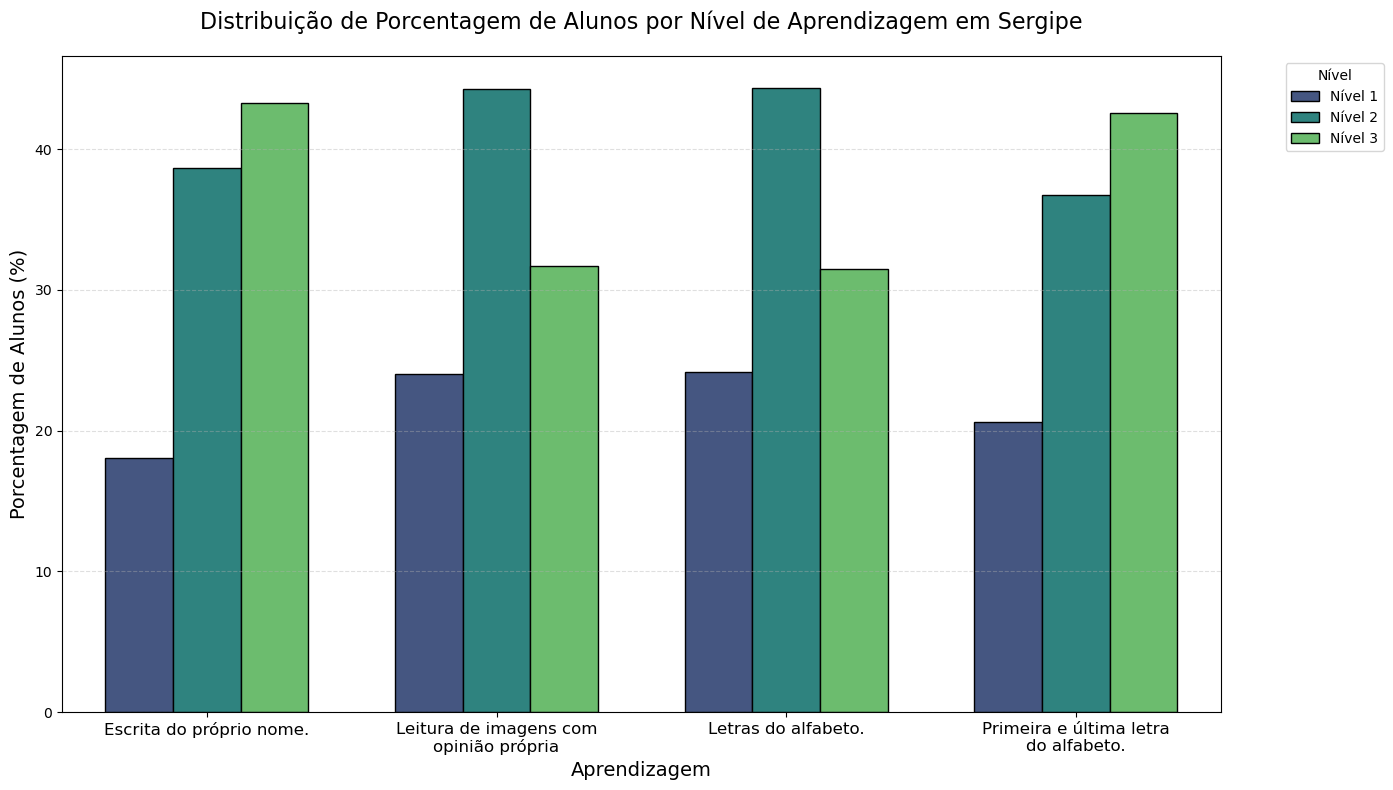

In [5]:
# Criando dfs para cada avaliação realizada
df_registros_diag = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA DIAGNÓSTICA – RETRATO DE ENTRADA']
df_registros_form_1 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 1']
df_registros_form_2 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 2']
df_registros_form_3 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 3']
df_registros_form_4 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 4']
df_registros_soma = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA SOMATIVA']

# Agrupando dados de nível e prática de linguagem
df_analise_diag_geral = df_registros_diag.groupby(['aprendizagem', 'nivel']).size().unstack(fill_value=0)
df_analise_diag_geral['total'] = df_analise_diag_geral[['Nível 1', 'Nível 2', 'Nível 3']].sum(axis=1)

# Agrupando dados de nível em porcentagem
porcentagem_diag_nivel_estado = df_analise_diag_geral[['Nível 1', 'Nível 2', 'Nível 3']].div(df_analise_diag_geral['total'], axis=0) * 100


# Criando gráfico de barras para análise geral da avaliação diagnóstica
# Criando diretório para salvar os gráficos
output_dir = "Data_files/graficos_diagnostica"
os.makedirs(output_dir, exist_ok=True)

# 1. Preparar os dados (formato long)
df_long = porcentagem_diag_nivel_estado.reset_index().melt(
    id_vars='aprendizagem', 
    var_name='nivel', 
    value_name='contagem'
)

# 2. Definir quais rótulos serão quebrados em duas linhas
rotulos_quebrados = []
for rotulo in porcentagem_diag_nivel_estado.index:
    if rotulo == "Leitura de imagens com opinião própria":
        rotulo = "Leitura de imagens com\nopinião própria"
    elif rotulo == "Primeira e última letra do alfabeto.":
        rotulo = "Primeira e última letra\ndo alfabeto."
    rotulos_quebrados.append(rotulo)

# 3. Configurar o gráfico
plt.figure(figsize=(14, 8))  # Aumentei a altura para acomodar as quebras
ax = sns.barplot(
    data=df_long,
    x='aprendizagem',
    y='contagem',
    hue='nivel',
    palette='viridis',
    edgecolor='black',
    width=0.7  # Barras um pouco mais estreitas
)

# 4. Ajustar os rótulos do eixo X
ax.set_xticks(range(len(porcentagem_diag_nivel_estado.index)))
ax.set_xticklabels(
    rotulos_quebrados,  # Usa os rótulos modificados
    rotation=0,
    ha='center',
    fontsize=12,
    linespacing=1.2  # Espaçamento entre linhas
)

# 5. Ajustar margens e layout
plt.gcf().subplots_adjust(bottom=0.3)  # Mais espaço na parte inferior
plt.title('Distribuição de Porcentagem de Alunos por Nível de Aprendizagem em Sergipe', fontsize=16, pad=20)
plt.xlabel('Aprendizagem', fontsize=14)
plt.ylabel('Porcentagem de Alunos (%)', fontsize=14)
plt.legend(title='Nível', bbox_to_anchor=(1.05, 1), loc='upper left')

# 6. Adicionar grid para melhor leitura
plt.grid(axis='y', linestyle='--', alpha=0.4)

# 7. Salvar o gráfico
plt.savefig(os.path.join(output_dir, 'grafico_diagnostica_sergipe.png'), bbox_inches='tight', dpi=300)

# 8. Exibir o gráfico 
plt.tight_layout()
plt.show()


Observação: 

Gerando informações gerais sobre relatório de turmas

In [6]:
# Tratando dados de relatórios:
mapeamento_respostas = {
    'pergunta_1': {
        'Busca por novo emprego.': 'Busca\npor emprego'
    },
    'pergunta_3': {
        'Apresenta alta motivação e foco no aprendizado.': 'Muito interessado',
        'Demonstra interesse moderado, mas com dificuldades em manter o foco.': 'Interesse moderado',
        'Parcialmente. Realiza algumas atividades, mas ainda necessita de muita ajuda.': 'Parcialmente interessado',
        'Mostra-se desinteressado ou pouco motivado.': 'Desinteressado'
    },
    'pergunta_4': {
        'Parcialmente. Realiza algumas atividades, mas ainda necessita de muita ajuda.': 'Parcialmente',
        'Não. Somente com ajuda.': 'Não',
        'Sim. Alta autonomia, consegue executar as tarefas com pouca ou nenhuma orientação.': 'Sim',
        'Reconhece suas inseguranças, mas tenta superá-las.': 'Reconhece inseguranças',
        'Apresenta alta capacidade de enfrentar as dificuldades e seguir adiante.': 'Alta independência'
    },
    'pergunta_5': {
        'Reconhece suas inseguranças, mas tenta superá-las.': 'Reconhece inseguranças',
        'Demonstra insegurança evidente, evita atividades desafiadoras.': 'Insegurança evidente',
        'Apresenta alta capacidade de enfrentar as dificuldades e seguir adiante.': 'Alta independência',
        'Persiste e busca melhorar, encarando os erros como parte do processo.': 'Busca melhorar',
        'Participam ativamente, colaboram e interagem com os colegas': 'Participação ativa',
        'Persiste, mas demonstra frustração.': 'Persiste com frustração'
    },
    'pergunta_6': {
        'Persiste e busca melhorar, encarando os erros como parte do processo.': 'Busca melhorar',
        'Persiste, mas demonstra frustração.': 'Persiste com frustração',
        'Participam ativamente, colaboram e interagem com os colegas': 'Participação ativa',
        'Demonstra insegurança evidente, evita atividades desafiadoras.': 'Insegurança evidente',
        'Dificuldade significativa em leitura e escrita.': 'Dificuldade significativa',
    },
    'pergunta_7': {
        'Participam ativamente, colaboram e interagem com os colegas': 'Participação ativa',
        'Participam ocasionalmente, mas sem muita iniciativa.': 'Participação ocasional',
        'Dificuldades em algumas áreas.': 'Algumas dificuldades',
        'Dificuldade significativa em leitura e escrita.': 'Dificuldade significativa',
        'Facilidade em aplicar o aprendizado em diferentes contextos do cotidiano.': 'Facilidade de aplicação do aprendizado',
        'Consegue ler e escrever com confiança.': 'Confiança em leitura e escrita'
    },
    'pergunta_8': {
        'Dificuldade significativa em leitura e escrita.': 'Dificuldade significativa',
        'Consegue ler e escrever com confiança.': 'Confiança em leitura e escrita',
        'Facilidade em aplicar o aprendizado em diferentes contextos do cotidiano.': 'Facilidade de aplicação do aprendizado',
        'Alta valorização, percebe o impacto positivo do aprendizado em sua vida.': 'Alta valorização'
    },
    'pergunta_9': {
        'Dificuldade em aplicar o aprendizado.': 'Dificuldade em aplicar,',
        'Facilidade em aplicar o aprendizado em diferentes contextos do cotidiano.': 'Facilidade de aplicação',
        'Alta valorização, percebe o impacto positivo do aprendizado em sua vida.': 'Alta valorização',
        'Valoriza parcialmente, mas ainda tem dificuldades em ver utilidade prática.': 'Valoriza parcialmente'
    },
    'pergunta_10': {
        'Alta valorização, percebe o impacto positivo do aprendizado em sua vida.': 'Alta valorização',
        'Valoriza parcialmente, mas ainda tem dificuldades em ver utilidade prática.': 'Valoriza parcialmente'
    }
}

# Aplicar o mapeamento
for pergunta, mapeamento in mapeamento_respostas.items():
    if pergunta in df_relatorios_diagnostica.columns:
        df_relatorios_diagnostica[pergunta] = df_relatorios_diagnostica[pergunta].replace(mapeamento)
        

In [7]:
# Dicionário com os títulos descritivos
titulos_perguntas = {
    'pergunta_1': '1. O que os motiva a voltar a estudar?',
    'pergunta_2': '2. Quais as perspectivas das turmas quanto a alfabetização e letramento?',
    'pergunta_3': '3. Quanto ao interesse pelo processo de alfabetização,as turmas:',
    'pergunta_4': '4. As turmas conseguem realizar atividades de forma independente?',
    'pergunta_5': '5. O que as turmas fazem quando não entendem algo?',
    'pergunta_6': '6. Como as turmas reagem diante de erros ou falhas?',
    'pergunta_7': '7. Como as turmas se comportam durante atividades em grupo?',
    'pergunta_8': '8. Quanto a leitura de palavras simples e escrita de sílabas/letra, as turmas:',
    'pergunta_9': '9. Em relação a aplicação do conhecimento em situações práticas, as turmas:',
    'pergunta_10': '10. Como as turmas valorizam o saber no dia a dia?'
}

# Configurações iniciais
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

# Função para quebrar textos longos
def quebrar_texto(texto, max_length=15):
    if pd.isna(texto):
        return texto
    return '\n'.join(textwrap.wrap(str(texto), width=max_length))

# 1. Preparação dos dados (igual ao anterior)
analise_perguntas = pd.DataFrame()
for pergunta in [f'pergunta_{i}' for i in range(1, 11)]:
    contagem = df_relatorios_diagnostica[pergunta].value_counts().reset_index()
    contagem.columns = ['resposta', 'contagem']
    contagem['porcentagem'] = (contagem['contagem'] / contagem['contagem'].sum()) * 100
    contagem['pergunta'] = pergunta
    contagem['resposta_formatada'] = contagem['resposta'].apply(quebrar_texto)
    analise_perguntas = pd.concat([analise_perguntas, contagem])

# 2. Gerar e salvar gráficos em arquivos separados
for file_num in range(5):
    fig, axes = plt.subplots(1, 2, figsize=(22, 12))
    plt.subplots_adjust(wspace=0.4, hspace=0.5)
    
    start_idx = file_num * 2
    end_idx = start_idx + 2
    
    for i, pergunta in enumerate([f'pergunta_{j}' for j in range(start_idx+1, end_idx+1)]):
        dados = analise_perguntas[analise_perguntas['pergunta'] == pergunta].sort_values('porcentagem', ascending=False)
        
        # Gráfico Seaborn - REMOVER RÓTULOS DO EIXO X
        ax = sns.barplot(
            data=dados,
            x='resposta_formatada',
            y='porcentagem',
            hue='resposta_formatada',
            palette='viridis',
            dodge=False,
            ax=axes[i],
            legend=False
        )
        
        # Remover rótulos do eixo X
        ax.set_xticklabels([])
        ax.set_xlabel('')
        
        # Títulos e labels
        ax.set_title(titulos_perguntas[pergunta], fontsize=18, pad=25)
        ax.set_ylabel('Porcentagem (%)', fontsize=14)
        
        # Ajustar eixo y
        ax.set_ylim(0, min(100, dados['porcentagem'].max() * 1.2))
        sns.despine(left=True)
        
        # Adicionar valores nas barras
        for p in ax.patches:
            ax.annotate(
                f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize=14
            )
        
        # CRIAR LEGENDA NA ÁREA VAZIA
        handles = [plt.Rectangle((0,0),1,1, color=color) for color in sns.color_palette("viridis", len(dados))]
        ax.legend(
            handles=handles,
            labels=list(dados['resposta_formatada']),
            title='Respostas',
            bbox_to_anchor=(0.9, 0.9),  # Posição relativa ao gráfico
            loc='upper left',
            borderaxespad=0.,
            frameon=True,
            fontsize=14,
            title_fontsize=16
        )
        
        ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Salvar figura
    output_path = os.path.join(output_dir, f'graficos_relatorio_diag_{file_num+1}.png')
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close()

print(f"✅ Gráficos salvos em: {os.path.abspath(output_dir)}")
analise_perguntas.sort_values(['pergunta', 'porcentagem'], ascending=[True, False])


✅ Gráficos salvos em: /home/fabcmc/GitHub Files/FGV/pba_se_2025/Data_files/graficos_diagnostica


,resposta,contagem,porcentagem,pergunta,resposta_formatada
0,Desejo de aprender.,258,93.818182,pergunta_1,Desejo de\naprender.
1,Incentivo da família.,11,4.000000,pergunta_1,Incentivo da\nfamília.
2,Outros,4,1.454545,pergunta_1,Outros
3,Busca\npor emprego,2,0.727273,pergunta_1,Busca por\nemprego
0,Alta valorização,180,65.454545,pergunta_10,Alta\nvalorização
...,...,...,...,...,...
1,"Dificuldade em aplicar,",54,19.636364,pergunta_9,"Dificuldade em\naplicar,"
2,Facilidade de aplicação,49,17.818182,pergunta_9,Facilidade de\naplicação
3,Valoriza parcialmente,4,1.454545,pergunta_9,Valoriza\nparcialmente
4,Outros,3,1.090909,pergunta_9,Outros


In [8]:
#df_analise_diag_geral
porcentagem_diag_nivel_estado

nivel,Nível 1,Nível 2,Nível 3
aprendizagem,,,
Escrita do próprio nome.,18.062201,38.684211,43.253589
Leitura de imagens com opinião própria,24.019139,44.258373,31.722488
Letras do alfabeto.,24.162679,44.377990,31.459330
Primeira e última letra do alfabeto.,20.645933,36.770335,42.583732


## Estudando os dados por estado
Agora vamos entender os dados de cada município. Dessa forma, nosso objetivo aqui é:
- Entender a quantidade de alunos por município e sua proporção em relação ao programa como um todo;
- Entender a quantidade de turmas por município e sua proporção em relação ao programa como um todo;
- Entender a relevância dos alunos perante o total de alunos enturmados em Sergipe;
- Gerar os resultados dos registros por atividade estruturada por município;
- Gerar os resultados de perfil de turma por município e entender se os perfis são diferentes.

### Entendendo alunos e turmas por município

In [9]:
# Criar uma cópia para trabalhar sem modificar o original
df_trabalho = df_cadastro.copy()

# Certificando que 'turma' tem o mesmo tipo em ambos os DataFrames
df_trabalho['turma'] = df_trabalho['turma'].astype(str).str.strip()
df_turmas['turma'] = df_turmas['turma'].astype(str).str.strip()

# Executando o merge
df_trabalho = df_trabalho.merge(
    df_turmas[['turma', 'municipio']], 
    on='turma', 
    how='left'
)

# Contando número de alunos e turmas por município
df_dados_municipios = df_trabalho.groupby('municipio').agg(
    numero_alunos=('nome', 'count'),
    numero_turmas=('turma', 'nunique')
).reset_index()

# Calculando média de alunos por turma por município e entendendo a relevância de cada município perante ao total de alunos enturmados
df_dados_municipios['media_alunos_por_turma'] = df_dados_municipios['numero_alunos'] / df_dados_municipios['numero_turmas']
df_dados_municipios['relevancia'] = df_dados_municipios['numero_alunos'] * 100 / enturmados

# Separando número de alunos por turma em cada município
turmas_e_municipios = df_turmas[['turma', 'municipio']]
turmas_e_municipios = turmas_e_municipios.rename(columns={'qtd._alfabetizandos': 'total_turma'})

# Entendendo quantidade de alunos em cada nível por turma em cada município
contagem_alunos_turma_diag = df_registros_diag.groupby('turma')['nome'].nunique().reset_index()
contagem_diag_turma = df_registros_diag.groupby(['turma', 'aprendizagem', 'nivel']).size().unstack(fill_value=0).reset_index()
contagem_diag_turma['total_turma'] = contagem_diag_turma[['Nível 1', 'Nível 2', 'Nível 3']].sum(axis=1)
contagem_diag_turma = contagem_diag_turma.merge(turmas_e_municipios, on='turma', how='left')
contagem_diag_municipio = contagem_diag_turma.groupby(['municipio', 'turma', 'total_turma', 'aprendizagem'])[['Nível 1', 'Nível 2', 'Nível 3']].sum().reset_index()

# Entendendo a realidade dos níveis para cada município usando média ponderada para unificar os dados
#media_diag_nivel_municipio = contagem_diag_municipio.groupby(['municipio', 'aprendizagem']).apply(lambda x: pd.Series({
#    'media_nivel_1': (x['Nível 1'] * x['total_turma']).sum() / x['total_turma'].sum(),
#    'media_nivel_2': (x['Nível 2'] * x['total_turma']).sum() / x['total_turma'].sum(),
#    'media_nivel_3': (x['Nível 3'] * x['total_turma']).sum() / x['total_turma'].sum()
#    })).reset_index() # Peso da média ponderada é a quantidade de alunos por turma

# Imprimindo as primeiras linhas do DataFrame resultante
#print(media_diag_nivel_municipio.head())
#contagem_alunos_turma_diag.head()
#teste = turmas_e_municipios.groupby('municipio')['total_turma'].sum().reset_index()
#teste[teste['municipio'] == 'NOSSA SENHORA DO SOCORRO']
contagem_diag_municipio.head()


/tmp/ipykernel_66879/55631242.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  contagem_diag_turma = df_registros_diag.groupby(['turma', 'aprendizagem', 'nivel']).size().unstack(fill_value=0).reset_index()


,municipio,turma,total_turma,aprendizagem,Nível 1,Nível 2,Nível 3
0,AQUIDABÃ,TURMA-28005201-0003,10,Escrita do próprio nome.,2,2,6
1,AQUIDABÃ,TURMA-28005201-0003,10,Leitura de imagens com opinião própria,0,2,8
2,AQUIDABÃ,TURMA-28005201-0003,10,Letras do alfabeto.,3,6,1
3,AQUIDABÃ,TURMA-28005201-0003,10,Primeira e última letra do alfabeto.,3,3,4
4,AQUIDABÃ,TURMA-28005201-0004,16,Escrita do próprio nome.,11,4,1


Agora vamos classificar os municipios de acordo com as médias em nível 3 em ordem decrescente e entender quais municipios apresentam maiores valores de nível 3. Nosso objetivo é tentar entender se há um padrão geográfico.

/tmp/ipykernel_66879/1607288993.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  porcentagem_diag_nivel_municipio = contagem_diag_municipio.groupby(['municipio', 'aprendizagem']).apply(



Erro ao processar 'Escrita do próprio nome': The EPSG code is unknown. PROJ: internal_proj_create_from_database: /home/fabcmc/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


ERROR 1: PROJ: internal_proj_create_from_database: /home/fabcmc/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.



Erro ao processar 'Leitura de imagens': The EPSG code is unknown. PROJ: internal_proj_create_from_database: /home/fabcmc/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


ERROR 1: PROJ: internal_proj_create_from_database: /home/fabcmc/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.



Erro ao processar 'Letras do alfabeto': The EPSG code is unknown. PROJ: internal_proj_create_from_database: /home/fabcmc/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


ERROR 1: PROJ: internal_proj_create_from_database: /home/fabcmc/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.



Erro ao processar 'Primeira e última letra': The EPSG code is unknown. PROJ: internal_proj_create_from_database: /home/fabcmc/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


ERROR 1: PROJ: internal_proj_create_from_database: /home/fabcmc/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


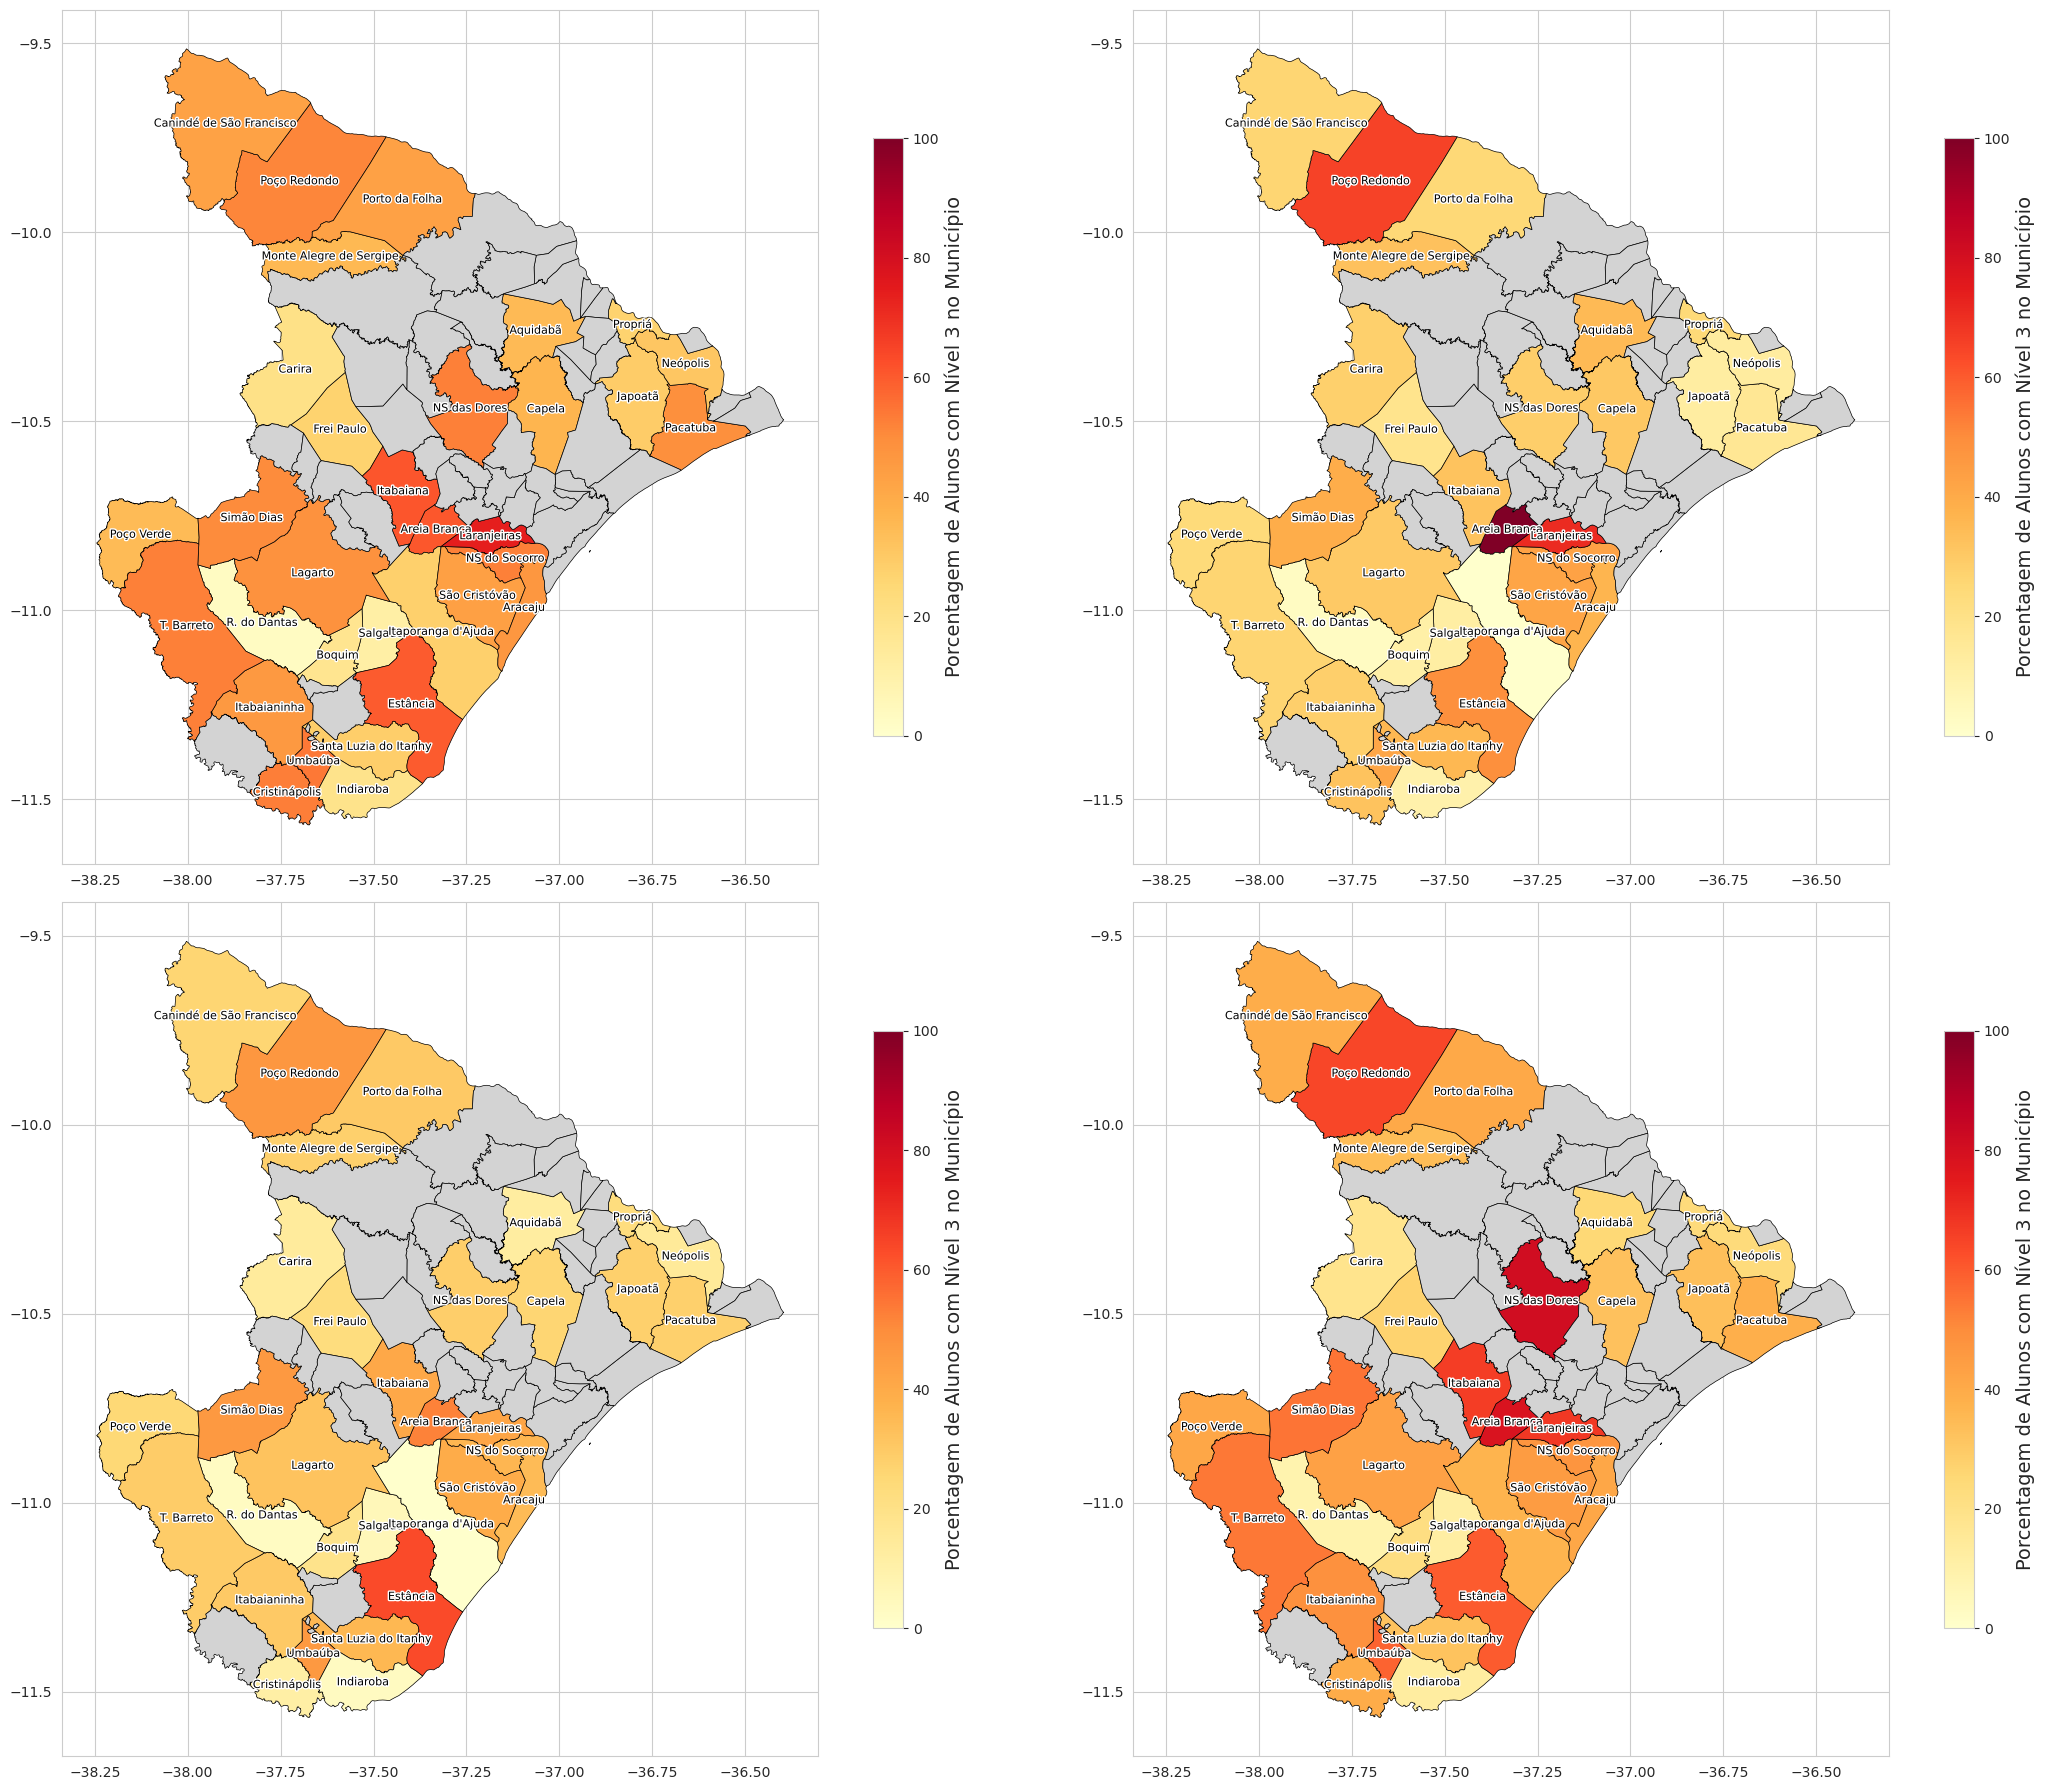

In [10]:
# Função para padronizar nomes de municípios
def padronizar_nomes(texto):
    return (
        texto.str.upper()
        .str.normalize('NFKD')  # Remove acentos
        .str.encode('ascii', errors='ignore')  # Converte para ASCII
        .str.decode('utf-8')  # Volta para UTF-8
        .str.replace(" DE ", " ")
        .str.replace(" DA ", " ")
        .str.replace(" DO ", " ")
        .str.strip()
    )

# 1. Cálculo das porcentagens (seu código original)
porcentagem_diag_nivel_municipio = contagem_diag_municipio.groupby(['municipio', 'aprendizagem']).apply(
    lambda x: pd.Series({
        'porcentagem_nivel_1': (x['Nível 1'].sum() * 100) / x['total_turma'].sum(),
        'porcentagem_nivel_2': (x['Nível 2'].sum() * 100) / x['total_turma'].sum(),
        'porcentagem_nivel_3': (x['Nível 3'].sum() * 100) / x['total_turma'].sum()
    })
).reset_index()

# 2. Classificação (seu código original)
primeira_e_ultima_letra = porcentagem_diag_nivel_municipio[
    porcentagem_diag_nivel_municipio['aprendizagem'] == 'Primeira e última letra do alfabeto.'].sort_values(by='porcentagem_nivel_3', ascending=False)
letras_do_alfabeto = porcentagem_diag_nivel_municipio[
    porcentagem_diag_nivel_municipio['aprendizagem'] == 'Letras do alfabeto.'].sort_values(by='porcentagem_nivel_3', ascending=False)
leitura_de_imagens = porcentagem_diag_nivel_municipio[
    porcentagem_diag_nivel_municipio['aprendizagem'] == 'Leitura de imagens com opinião própria'].sort_values(by='porcentagem_nivel_3', ascending=False)
escrita_do_nome = porcentagem_diag_nivel_municipio[
    porcentagem_diag_nivel_municipio['aprendizagem'] == 'Escrita do próprio nome.'].sort_values(by='porcentagem_nivel_3', ascending=False)

# 3. Padronização dos nomes ANTES da mesclagem
dfs_aprendizagens = [escrita_do_nome, leitura_de_imagens, letras_do_alfabeto, primeira_e_ultima_letra]

# Carregar shapefile
sergipe = gpd.read_file('Data_files/SE_Municipios_2024/SE_Municipios_2024.shp')

# Padronizar nomes no shapefile e nos DataFrames
sergipe['NM_MUN_PADRONIZADO'] = padronizar_nomes(sergipe['NM_MUN'])

for df in dfs_aprendizagens:
    df['municipio_padronizado'] = padronizar_nomes(df['municipio'])

# Função para abreviar "Nossa Senhora" para "NS"
def abreviar_nome(nome):
    return nome.replace(
        "Nossa Senhora", "NS").replace(
            "N.S.", "NS").replace(
                "Tobias Barreto", "T. Barreto").replace(
                    "Riachão do Dantas", "R. do Dantas")

# 4. Configuração dos plots
fig, axes = plt.subplots(2, 2, figsize=(22, 18))
axes = axes.flatten()

titulos = [
    'Escrita do próprio nome',
    'Leitura de imagens',
    'Letras do alfabeto',
    'Primeira e última letra'
]

# Loop para cada aprendizagem
for i, (df, titulo) in enumerate(zip(dfs_aprendizagens, titulos)):
    try:
        # Mesclagem com nomes padronizados
        sergipe_merged = sergipe.merge(
            df,
            left_on='NM_MUN_PADRONIZADO',
            right_on='municipio_padronizado',
            how='left'
        )
        
        # Plotagem
        ax = axes[i]
        sergipe_merged.plot(
            column='porcentagem_nivel_3',
            cmap='YlOrRd',
            legend=True,
            ax=ax,
            edgecolor='black',
            linewidth=0.5,
            missing_kwds={'color': 'lightgrey'},
            vmin=0,
            vmax=100,
            legend_kwds={'label': "Porcentagem de Alunos com Nível 3 no Município", 'shrink': 0.7}
        )
        
        # ADIÇÃO DOS NOMES DOS MUNICÍPIOS COM ABREVIAÇÃO
        for idx, row in sergipe_merged.iterrows():
            if not pd.isna(row['porcentagem_nivel_3']):
                nome_municipio = abreviar_nome(row['NM_MUN'])
                ax.annotate(
                    text=nome_municipio,  # Nome abreviado quando aplicável
                    xy=row['geometry'].centroid.coords[0],
                    ha='center',
                    va='center',
                    fontsize=8,
                    color='black',
                    path_effects=[patheffects.withStroke(linewidth=2, foreground="white")]
                )
        
        ctx.add_basemap(ax, crs=sergipe.crs, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.7)
        ax.set_title(f'Desempenho em {titulo} - % de Alunos com Nível 3', fontsize=14)
        ax.set_axis_off()
        
    except Exception as e:
        print(f"\nErro ao processar '{titulo}': {str(e)}")
        continue

plt.tight_layout()
plt.savefig(os.path.join(output_dir,'heatmaps_sergipe_diag.png'), dpi=300, bbox_inches='tight')

A partir desses resultados, vamos gerar os gráficos por município e entender a variabilidade dos dados através da barra de erro.

### Criando gráficos e exportando para relatórios

In [11]:
# Lista de municípios únicos
municipios = df_registros_diag['municipio'].unique()


# Criando loop para gerar gráficos
for municipio in municipios:
    # Filtrar dados para o município atual
    df_municipio = df_registros_diag[df_registros_diag['municipio'] == municipio]
    
    # Agrupar dados (igual ao seu processamento original)
    df_analise = df_municipio.groupby(['aprendizagem', 'nivel']).size().unstack(fill_value=0)
    df_analise['total'] = df_analise[['Nível 1', 'Nível 2', 'Nível 3']].sum(axis=1)
    
    # Agrupado dados em porcentagem
    porcentagem_nivel = df_analise[['Nível 1', 'Nível 2', 'Nível 3']].div(df_analise['total'], axis=0) * 100    
    
    # Preparar dados no formato longo
    df_long = porcentagem_nivel.reset_index().melt(
        id_vars='aprendizagem',
        var_name='nivel',
        value_name='contagem'
    )
    
    # Quebra de rótulos específicos (igual ao anterior)
    rotulos_quebrados = []
    for rotulo in porcentagem_nivel.index:
        if rotulo == "Leitura de imagens com opinião própria":
            rotulo = "Leitura de imagens com\nopinião própria"
        elif rotulo == "Primeira e última letra do alfabeto":
            rotulo = "Primeira e última letra\ndo alfabeto."
        rotulos_quebrados.append(rotulo)
    
    # Criar figura
    plt.figure(figsize=(14, 8))
    ax = sns.barplot(
        data=df_long,
        x='aprendizagem',
        y='contagem',
        hue='nivel',
        palette='viridis',
        edgecolor='black',
        width=0.7
    )
    
    # Formatação do gráfico
    ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)
    plt.title(f'Distribuição por Nível de Aprendizagem\nMunicípio: {municipio}', fontsize=16, pad=20)
    plt.xlabel('Aprendizagem', fontsize=14)
    plt.ylabel('Porcentagem de Alunos (%)', fontsize=14)
    plt.legend(title='Nível', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    
    # Salvar o gráfico
    nome_arquivo = f'grafico_diagnostica_{municipio.lower().replace(" ", "_")}.png'
    caminho_completo = os.path.join(output_dir, nome_arquivo)
    
    plt.savefig(
        caminho_completo,
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )
    
    plt.close()  # Fecha a figura para liberar memória
    
    print(f'Gráfico salvo: {caminho_completo}')

print("Processo concluído! Todos os gráficos foram gerados.")


/tmp/ipykernel_66879/842642549.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise = df_municipio.groupby(['aprendizagem', 'nivel']).size().unstack(fill_value=0)
/tmp/ipykernel_66879/842642549.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)


Gráfico salvo: Data_files/graficos_diagnostica/grafico_diagnostica_simão_dias.png


/tmp/ipykernel_66879/842642549.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise = df_municipio.groupby(['aprendizagem', 'nivel']).size().unstack(fill_value=0)
/tmp/ipykernel_66879/842642549.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)


Gráfico salvo: Data_files/graficos_diagnostica/grafico_diagnostica_aracaju.png


/tmp/ipykernel_66879/842642549.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise = df_municipio.groupby(['aprendizagem', 'nivel']).size().unstack(fill_value=0)
/tmp/ipykernel_66879/842642549.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)


...

Gráfico salvo: Data_files/graficos_diagnostica/grafico_diagnostica_cristinápolis.png


/tmp/ipykernel_66879/842642549.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise = df_municipio.groupby(['aprendizagem', 'nivel']).size().unstack(fill_value=0)
/tmp/ipykernel_66879/842642549.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)


Gráfico salvo: Data_files/graficos_diagnostica/grafico_diagnostica_nossa_senhora_das_dores.png


/tmp/ipykernel_66879/842642549.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise = df_municipio.groupby(['aprendizagem', 'nivel']).size().unstack(fill_value=0)
/tmp/ipykernel_66879/842642549.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)


Gráfico salvo: Data_files/graficos_diagnostica/grafico_diagnostica_riachão_do_dantas.png
Processo concluído! Todos os gráficos foram gerados.
